# Query method coverage comparison

Reads every `*.tsv` result file in this directory and computes coverage (recall) — the % of catalog resources with ≥ 1 result — per query method, against the full `tables/resources-inventory-Jun_8_2026.tab` inventory.

Uses `Resource Name` as the join key, not `Abbreviation` — 38/239 resources have a blank Abbreviation and 14 non-blank Abbreviations are duplicated across distinct resources, so it isn't a reliable unique key here. `Resource Name` has 0 blanks and only 2 duplicates.

This covers recall/coverage only. Precision (via paperclip claim-verification as a relevance oracle over every method's results) is a follow-up, not in this notebook yet.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

EXPERIMENTS_DIR = Path(".")
INVENTORY_PATH = "../../../../tables/resources-inventory-Jun_8_2026.tab"

In [2]:
inventory_df = pd.read_csv(INVENTORY_PATH, sep="\t", dtype=str)
all_resources = set(inventory_df["Resource Name"].dropna())
print(f"Total resources in catalog: {len(all_resources)}")

Total resources in catalog: 237


In [3]:
tsv_files = sorted(EXPERIMENTS_DIR.glob("*.tsv"))
print(f"Found {len(tsv_files)} result file(s):")
for f in tsv_files:
    print(" -", f.name)

datasets = {}
for f in tsv_files:
    label = f.stem  # e.g. "q1_pmc_full"
    df = pd.read_csv(f, sep="\t", dtype=str)
    datasets[label] = df

Found 10 result file(s):
 - paperclip_full_with_doc_ids.tsv
 - q1_pmc_full.tsv
 - q1_pubmed_full.tsv
 - q2_pmc_full.tsv
 - q2_pubmed_full.tsv
 - q3_pmc_full.tsv
 - q3_pubmed_full.tsv
 - q4_pmc_full.tsv
 - q4_pubmed_full.tsv
 - v5_pmc_full.tsv


In [4]:
rows = []
covered_by = {}
for label, df in datasets.items():
    present = set(df["Resource Name"].dropna()) if "Resource Name" in df.columns else set()
    covered = present & all_resources
    unmatched = present - all_resources
    covered_by[label] = covered
    rows.append({
        "Method": label,
        "Total rows": len(df),
        "Resources covered": len(covered),
        "Coverage %": round(len(covered) / len(all_resources) * 100, 1),
        "Unrecognized resource names": len(unmatched),
    })

coverage_df = pd.DataFrame(rows).sort_values("Coverage %", ascending=False).reset_index(drop=True)
coverage_df

,Method,Total rows,Resources covered,Coverage %,Unrecognized resource names
0,paperclip_full_with_doc_ids,1155,235,99.2,0
1,v5_pmc_full,21322,233,98.3,0
2,q2_pmc_full,9236,165,69.6,0
3,q4_pmc_full,8977,165,69.6,0
4,q1_pmc_full,6392,132,55.7,0
5,q3_pmc_full,5661,125,52.7,0
6,q2_pubmed_full,3205,99,41.8,0
7,q4_pubmed_full,2441,99,41.8,0
8,q1_pubmed_full,2842,95,40.1,0
9,q3_pubmed_full,1475,73,30.8,0


In [5]:
out_csv = EXPERIMENTS_DIR / "coverage_summary.csv"
coverage_df.to_csv(out_csv, index=False)
print(f"Saved \u2192 {out_csv}")

Saved → coverage_summary.csv


In [6]:
import re

def paperclip_source(doc_id: str) -> str:
    """Infer which underlying corpus a paperclip doc_id came from, from its ID format."""
    if doc_id.startswith("PMC"):
        return "PMC"
    m = re.match(r"^([a-z]+)_", doc_id)
    if m:
        return {"bio": "bioRxiv", "med": "medRxiv", "arx": "arXiv", "oa": "Abstracts"}.get(m.group(1), "Other")
    return "Other"

# Method families: label -> ordered list of (source, covered-resources). Order sets
# stacking priority — a resource is credited to the first segment that covers it,
# so segments within one bar are non-overlapping and sum to that method's total
# (union) coverage instead of double-counting resources covered by >1 source.
families = {
    "Q1 (original)": [("PubMed", covered_by.get("q1_pubmed_full", set())), ("PMC", covered_by.get("q1_pmc_full", set()))],
    "Q2": [("PubMed", covered_by.get("q2_pubmed_full", set())), ("PMC", covered_by.get("q2_pmc_full", set()))],
    "Q3": [("PubMed", covered_by.get("q3_pubmed_full", set())), ("PMC", covered_by.get("q3_pmc_full", set()))],
    "Q4 (fanout)": [("PubMed", covered_by.get("q4_pubmed_full", set())), ("PMC", covered_by.get("q4_pmc_full", set()))],
    "V5 (Claude + PMC)": [("PMC", covered_by.get("v5_pmc_full", set()))],
}

pc_df = datasets["paperclip_full_with_doc_ids"].copy()
pc_df = pc_df[pc_df["Resource Name"].isin(all_resources)]
pc_df["__source"] = pc_df["Paperclip Doc ID"].fillna("").apply(paperclip_source)
pc_source_order = ["PMC", "bioRxiv", "medRxiv", "Abstracts", "arXiv", "Other"]
families["Paperclip (full-text)"] = [
    (src, set(pc_df.loc[pc_df["__source"] == src, "Resource Name"])) for src in pc_source_order
]

stack_rows = []
for method, segments in families.items():
    seen = set()
    for source, covered in segments:
        new = covered - seen
        seen |= covered
        stack_rows.append({"Method": method, "Source": source, "Incremental %": len(new) / len(all_resources) * 100})

stack_df = pd.DataFrame(stack_rows)
stack_df

,Method,Source,Incremental %
0,Q1 (original),PubMed,40.084388
1,Q1 (original),PMC,17.299578
2,Q2,PubMed,41.772152
3,Q2,PMC,28.270042
4,Q3,PubMed,30.801688
5,Q3,PMC,23.628692
6,Q4 (fanout),PubMed,41.772152
7,Q4 (fanout),PMC,28.270042
8,V5 (Claude + PMC),PMC,98.312236
9,Paperclip (full-text),PMC,85.654008


Saved → coverage_comparison.png


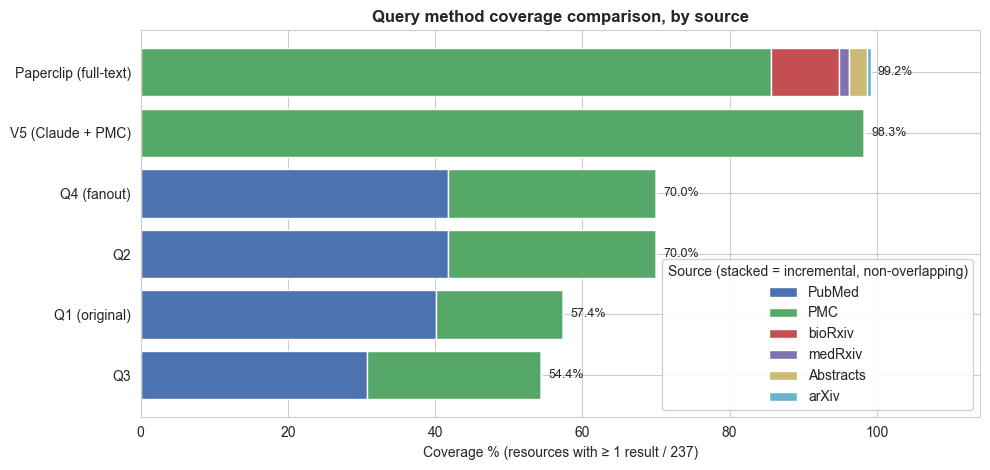

In [7]:
source_colors = {
    "PubMed": "#4C72B0",
    "PMC": "#55A868",
    "bioRxiv": "#C44E52",
    "medRxiv": "#8172B2",
    "Abstracts": "#CCB974",
    "arXiv": "#64B5CD",
    "Other": "#999999",
}

totals = stack_df.groupby("Method")["Incremental %"].sum()
method_order = totals.sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(10, max(3, 0.8 * len(method_order))))
left = pd.Series(0.0, index=method_order)
for source in [s for s in source_colors if s in stack_df["Source"].unique()]:
    seg = stack_df[stack_df["Source"] == source].set_index("Method")["Incremental %"].reindex(method_order).fillna(0)
    if seg.sum() == 0:
        continue
    ax.barh(method_order, seg, left=left[method_order], color=source_colors[source], label=source)
    left += seg

for i, m in enumerate(method_order):
    ax.text(totals[m] + 1, i, f"{totals[m]:.1f}%", va="center", fontsize=9)

ax.set_xlabel(f"Coverage % (resources with ≥ 1 result / {len(all_resources)})")
ax.set_title("Query method coverage comparison, by source", fontweight="bold")
ax.set_xlim(0, max(totals.max() * 1.15, 10))
ax.legend(loc="lower right", framealpha=0.9, title="Source (stacked = incremental, non-overlapping)")
plt.tight_layout()

out_png = EXPERIMENTS_DIR / "coverage_comparison.png"
fig.savefig(out_png, dpi=180, bbox_inches="tight")
print(f"Saved → {out_png}")
plt.show()

## Union / intersection across methods

How much does combining methods actually buy you, and which resources still have zero coverage from anything tried so far?

In [8]:
union_covered = set().union(*covered_by.values()) if covered_by else set()
intersection_covered = set.intersection(*covered_by.values()) if covered_by else set()
never_covered = all_resources - union_covered

print(f"Covered by ANY method:  {len(union_covered)}/{len(all_resources)} ({len(union_covered) / len(all_resources) * 100:.1f}%)")
print(f"Covered by ALL methods: {len(intersection_covered)}/{len(all_resources)} ({len(intersection_covered) / len(all_resources) * 100:.1f}%)")
print(f"Never covered by anything tried so far: {len(never_covered)}")

Covered by ANY method:  237/237 (100.0%)
Covered by ALL methods: 69/237 (29.1%)
Never covered by anything tried so far: 0


In [9]:
sorted(never_covered)

[]